JPMorgan Chase Quantitative Research - Task 3
Loan Default Prediction Model

This script builds a predictive model to estimate the probability of default (PD)
for borrowers based on their characteristics. The model helps the risk management
team anticipate potential losses and provision appropriate capital.

Key Objectives:
- Predict probability of default for each borrower
- Calculate expected loss assuming 10% recovery rate
- Compare multiple machine learning approaches
- Provide actionable insights for risk management

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# 1. DATA LOADING AND EXPLORATION

print("="*80)
print("LOAN DEFAULT PREDICTION MODEL")
print("="*80)

# Load the data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print("\n" + "─"*80)
print("1. DATA OVERVIEW")
print("─"*80)

print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

print(f"\nFirst few rows:")
print(df.head(10))

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nBasic statistics:")
print(df.describe())

LOAN DEFAULT PREDICTION MODEL

────────────────────────────────────────────────────────────────────────────────
1. DATA OVERVIEW
────────────────────────────────────────────────────────────────────────────────

Dataset shape: 10000 rows × 8 columns

Columns: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']

First few rows:
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   
5      4661159                         0           5376.886873   
6      8291909                         1           3634.057471   
7      4616950                         4         


────────────────────────────────────────────────────────────────────────────────
2. EXPLORATORY DATA ANALYSIS
────────────────────────────────────────────────────────────────────────────────

Target Variable Distribution:
  Non-default (0): 8,149 (81.49%)
  Default (1):     1,851 (18.51%)
  Default rate:    18.51%

Feature statistics by default status:
          customer_id  credit_lines_outstanding  loan_amt_outstanding  \
default                                                                 
0        4.967005e+06                  0.744140           4092.629025   
1        5.007914e+06                  4.618044           4454.854897   

         total_debt_outstanding        income  years_employed  fico_score  
default                                                                    
0                   6322.164549  69883.889804        4.765247  646.938765  
1                  19270.582961  70726.740140        3.617504  596.257699  

Correlation with default:
default             

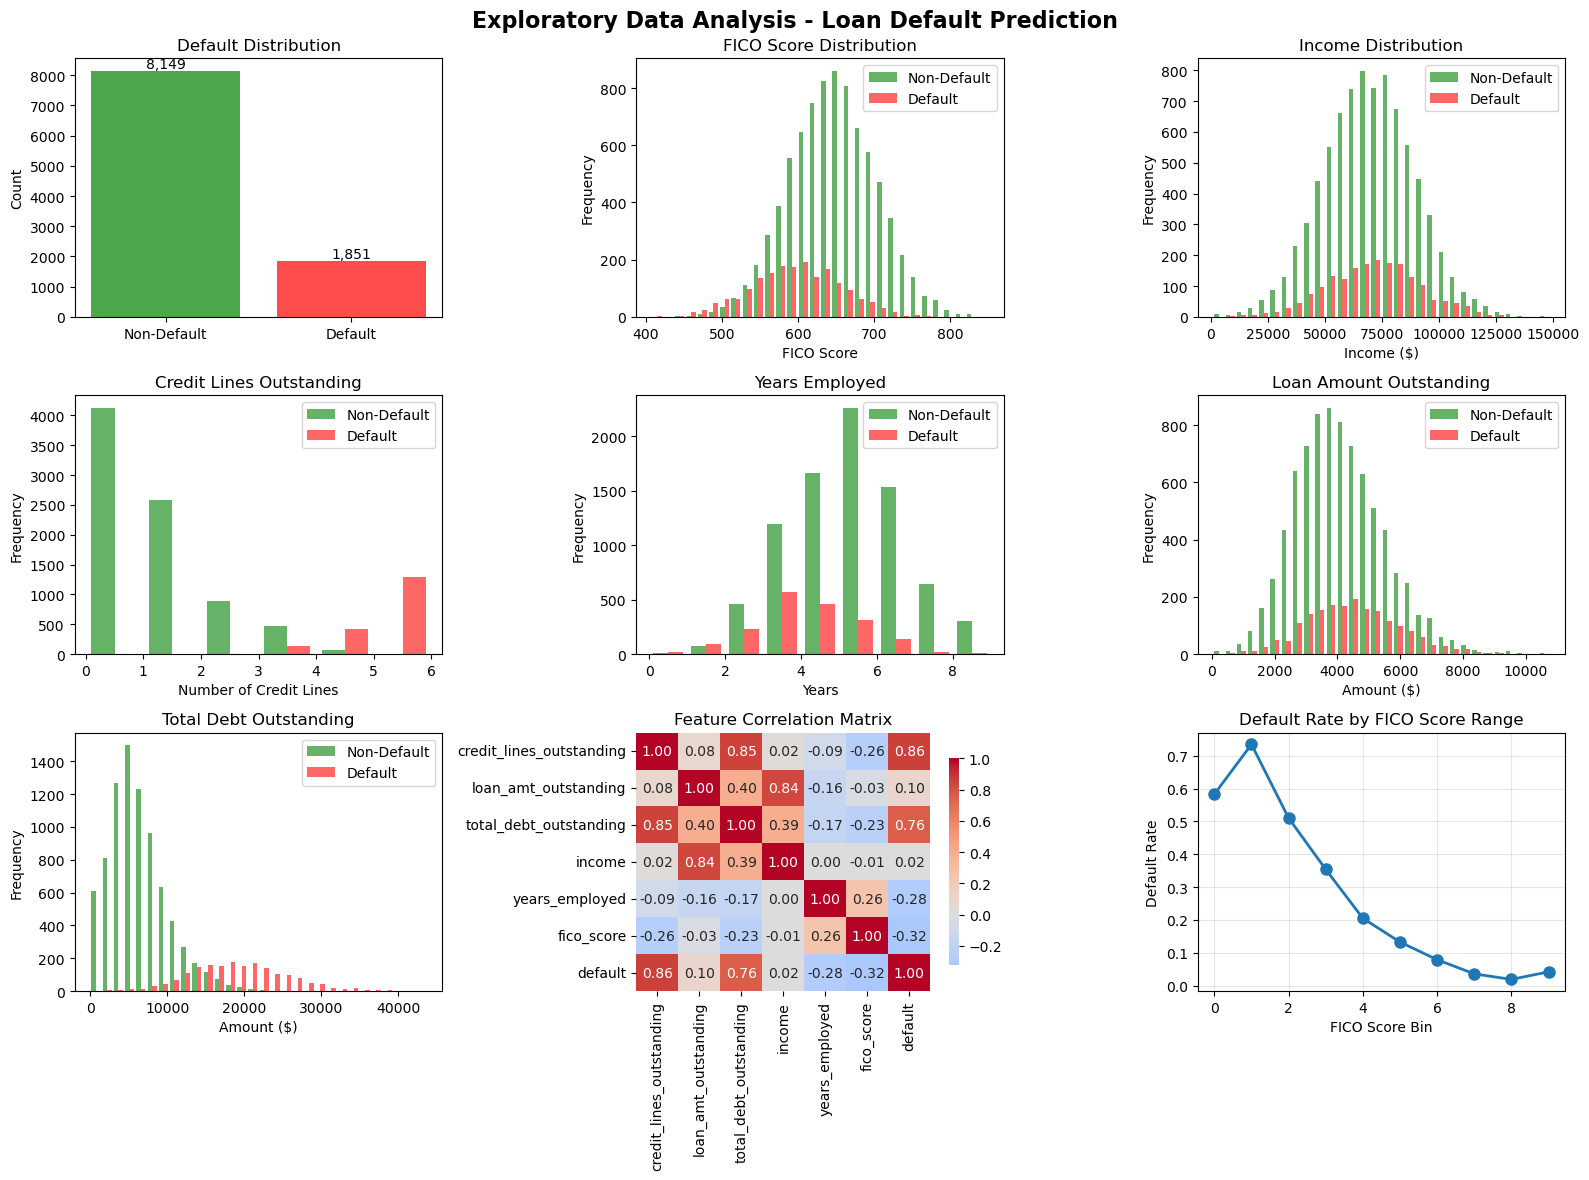

In [6]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)

print("\n" + "─"*80)
print("2. EXPLORATORY DATA ANALYSIS")
print("─"*80)

# Target variable distribution
default_counts = df['default'].value_counts()
default_rate = df['default'].mean()

print(f"\nTarget Variable Distribution:")
print(f"  Non-default (0): {default_counts[0]:,} ({(1-default_rate)*100:.2f}%)")
print(f"  Default (1):     {default_counts[1]:,} ({default_rate*100:.2f}%)")
print(f"  Default rate:    {default_rate*100:.2f}%")

# Feature statistics by default status
print(f"\nFeature statistics by default status:")
print(df.groupby('default').mean())

# Correlation analysis
print(f"\nCorrelation with default:")
correlations = df.corr()['default'].sort_values(ascending=False)
print(correlations)

# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis - Loan Default Prediction', 
             fontsize=16, fontweight='bold')

# 1. Default distribution
axes[0, 0].bar(['Non-Default', 'Default'], default_counts.values, 
               color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Default Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(default_counts.values):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 2. FICO score distribution by default
axes[0, 1].hist([df[df['default']==0]['fico_score'], 
                 df[df['default']==1]['fico_score']], 
                bins=30, label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[0, 1].set_title('FICO Score Distribution')
axes[0, 1].set_xlabel('FICO Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Income distribution by default
axes[0, 2].hist([df[df['default']==0]['income'], 
                 df[df['default']==1]['income']], 
                bins=30, label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[0, 2].set_title('Income Distribution')
axes[0, 2].set_xlabel('Income ($)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()

# 4. Credit lines outstanding
axes[1, 0].hist([df[df['default']==0]['credit_lines_outstanding'], 
                 df[df['default']==1]['credit_lines_outstanding']], 
                bins=range(0, 7), label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[1, 0].set_title('Credit Lines Outstanding')
axes[1, 0].set_xlabel('Number of Credit Lines')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 5. Years employed
axes[1, 1].hist([df[df['default']==0]['years_employed'], 
                 df[df['default']==1]['years_employed']], 
                bins=range(0, 10), label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[1, 1].set_title('Years Employed')
axes[1, 1].set_xlabel('Years')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

# 6. Loan amount outstanding
axes[1, 2].hist([df[df['default']==0]['loan_amt_outstanding'], 
                 df[df['default']==1]['loan_amt_outstanding']], 
                bins=30, label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[1, 2].set_title('Loan Amount Outstanding')
axes[1, 2].set_xlabel('Amount ($)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend()

# 7. Total debt outstanding
axes[2, 0].hist([df[df['default']==0]['total_debt_outstanding'], 
                 df[df['default']==1]['total_debt_outstanding']], 
                bins=30, label=['Non-Default', 'Default'], 
                color=['green', 'red'], alpha=0.6)
axes[2, 0].set_title('Total Debt Outstanding')
axes[2, 0].set_xlabel('Amount ($)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].legend()

# 8. Correlation heatmap
features_for_corr = ['credit_lines_outstanding', 'loan_amt_outstanding', 
                     'total_debt_outstanding', 'income', 'years_employed', 
                     'fico_score', 'default']
corr_matrix = df[features_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[2, 1], cbar_kws={'shrink': 0.8})
axes[2, 1].set_title('Feature Correlation Matrix')

# 9. Default rate by FICO score bins
fico_bins = pd.cut(df['fico_score'], bins=10)
default_by_fico = df.groupby(fico_bins)['default'].mean()
axes[2, 2].plot(range(len(default_by_fico)), default_by_fico.values, 
                marker='o', linewidth=2, markersize=8)
axes[2, 2].set_title('Default Rate by FICO Score Range')
axes[2, 2].set_xlabel('FICO Score Bin')
axes[2, 2].set_ylabel('Default Rate')
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
print("\n EDA visualization saved: eda_analysis.png")

In [7]:
# 3. DATA PREPARATION

print("\n" + "─"*80)
print("3. DATA PREPARATION")
print("─"*80)

# Separate features and target
X = df.drop(['customer_id', 'default'], axis=1)
y = df['default']

print(f"\nFeatures: {list(X.columns)}")
print(f"Target: default")

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Default rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test:  {y_test.mean()*100:.2f}%")

# Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Features scaled using StandardScaler")


────────────────────────────────────────────────────────────────────────────────
3. DATA PREPARATION
────────────────────────────────────────────────────────────────────────────────

Features: ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']
Target: default

Training set: 8000 samples
Testing set:  2000 samples
Default rate in train: 18.51%
Default rate in test:  18.50%

 Features scaled using StandardScaler


In [8]:
# 4. MODEL TRAINING - MULTIPLE APPROACHES

print("\n" + "─"*80)
print("4. MODEL TRAINING - COMPARING MULTIPLE APPROACHES")
print("─"*80)

# Dictionary to store all models
models = {}
results = {}

# ─────────────────────────────────────────────────────────────────────────
# Model 1: Logistic Regression
# ─────────────────────────────────────────────────────────────────────────
print("\n[1/4] Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model

# Get predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Store results
results['Logistic Regression'] = {
    'predictions': y_pred_lr,
    'probabilities': y_pred_proba_lr,
    'scaled': True
}

print("✓ Logistic Regression trained")

# ─────────────────────────────────────────────────────────────────────────
# Model 2: Decision Tree
# ─────────────────────────────────────────────────────────────────────────
print("\n[2/4] Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, 
                                  min_samples_split=50, min_samples_leaf=20)
dt_model.fit(X_train, y_train)
models['Decision Tree'] = dt_model

y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

results['Decision Tree'] = {
    'predictions': y_pred_dt,
    'probabilities': y_pred_proba_dt,
    'scaled': False
}

print("Decision Tree trained")

# ─────────────────────────────────────────────────────────────────────────
# Model 3: Random Forest
# ─────────────────────────────────────────────────────────────────────────
print("\n[3/4] Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, 
                                  max_depth=15, min_samples_split=50, 
                                  min_samples_leaf=20, n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'predictions': y_pred_rf,
    'probabilities': y_pred_proba_rf,
    'scaled': False
}

print("Random Forest trained")

# ─────────────────────────────────────────────────────────────────────────
# Model 4: Gradient Boosting
# ─────────────────────────────────────────────────────────────────────────
print("\n[4/4] Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, 
                                     max_depth=5, learning_rate=0.1)
gb_model.fit(X_train, y_train)
models['Gradient Boosting'] = gb_model

y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

results['Gradient Boosting'] = {
    'predictions': y_pred_gb,
    'probabilities': y_pred_proba_gb,
    'scaled': False
}

print("Gradient Boosting trained")



────────────────────────────────────────────────────────────────────────────────
4. MODEL TRAINING - COMPARING MULTIPLE APPROACHES
────────────────────────────────────────────────────────────────────────────────

[1/4] Training Logistic Regression...
✓ Logistic Regression trained

[2/4] Training Decision Tree...
Decision Tree trained

[3/4] Training Random Forest...
Random Forest trained

[4/4] Training Gradient Boosting...
Gradient Boosting trained



5. MODEL PERFORMANCE COMPARISON

 PERFORMANCE METRICS:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.9980   1.000000 0.989189  0.994565 0.999990
  Gradient Boosting    0.9975   0.994580 0.991892  0.993234 0.999920
      Random Forest    0.9870   0.964865 0.964865  0.964865 0.999388
      Decision Tree    0.9950   0.989130 0.983784  0.986450 0.998518

 BEST MODEL: Logistic Regression
   ROC-AUC Score: 1.0000

────────────────────────────────────────────────────────────────────────────────
DETAILED EVALUATION - Logistic Regression
────────────────────────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

 Non-Default       1.00      1.00      1.00      1630
     Default       1.00      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      

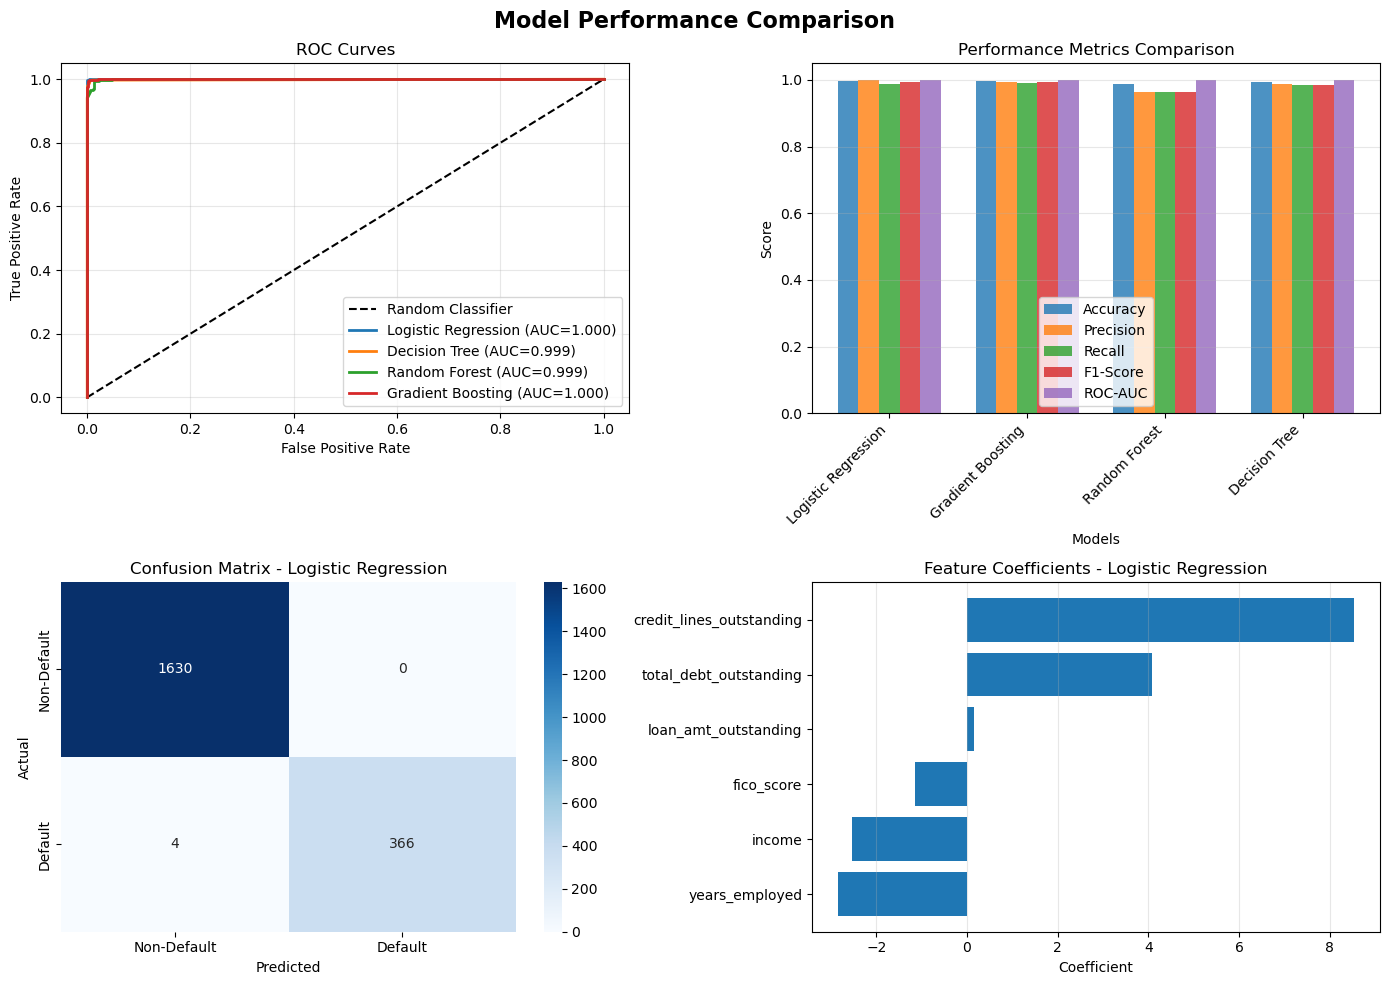

In [9]:
# 5. MODEL EVALUATION

print("\n" + "="*80)
print("5. MODEL PERFORMANCE COMPARISON")
print("="*80)

# Create comparison table
comparison_data = []

for model_name, model_results in results.items():
    y_pred = model_results['predictions']
    y_pred_proba = model_results['probabilities']
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n PERFORMANCE METRICS:")
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
best_results = results[best_model_name]

print(f"\n BEST MODEL: {best_model_name}")
print(f"   ROC-AUC Score: {comparison_df.iloc[0]['ROC-AUC']:.4f}")

# Detailed evaluation of best model
print(f"\n" + "─"*80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("─"*80)

y_pred_best = best_results['predictions']
y_pred_proba_best = best_results['probabilities']

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, 
                           target_names=['Non-Default', 'Default']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(f"                 Predicted")
print(f"                 Non-Default  Default")
print(f"Actual Non-Default    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual Default        {cm[1,0]:5d}      {cm[1,1]:5d}")

# Feature importance (for tree-based models)
if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    print(f"\nFeature Importance:")
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    for idx, row in feature_importance.iterrows():
        print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. ROC Curves
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
for model_name, model_results in results.items():
    y_pred_proba = model_results['probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    axes[0, 0].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x_pos = np.arange(len(comparison_df))
width = 0.15

for i, metric in enumerate(metrics):
    axes[0, 1].bar(x_pos + i*width, comparison_df[metric], 
                   width, label=metric, alpha=0.8)

axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Performance Metrics Comparison')
axes[0, 1].set_xticks(x_pos + width * 2)
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Confusion matrix for best model
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# 4. Feature importance (if applicable)
if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    feature_importance_sorted = feature_importance.sort_values('Importance')
    axes[1, 1].barh(range(len(feature_importance_sorted)), 
                    feature_importance_sorted['Importance'])
    axes[1, 1].set_yticks(range(len(feature_importance_sorted)))
    axes[1, 1].set_yticklabels(feature_importance_sorted['Feature'])
    axes[1, 1].set_xlabel('Importance')
    axes[1, 1].set_title(f'Feature Importance - {best_model_name}')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
else:
    # For logistic regression, show coefficients
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lr_model.coef_[0]
    }).sort_values('Coefficient')
    
    axes[1, 1].barh(range(len(coef_df)), coef_df['Coefficient'])
    axes[1, 1].set_yticks(range(len(coef_df)))
    axes[1, 1].set_yticklabels(coef_df['Feature'])
    axes[1, 1].set_xlabel('Coefficient')
    axes[1, 1].set_title(f'Feature Coefficients - {best_model_name}')
    axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\nModel comparison visualization saved: model_comparison.png")


In [10]:
# 6. EXPECTED LOSS CALCULATION FUNCTION

print("\n" + "="*80)
print("6. EXPECTED LOSS CALCULATION")
print("="*80)

def calculate_expected_loss(loan_features, model=best_model, scaler=scaler, 
                           recovery_rate=0.10, use_scaling=best_results['scaled']):
    """
    Calculate the expected loss for a loan given borrower features.
    
    Parameters:
    -----------
    loan_features : dict
        Dictionary containing borrower features:
        - credit_lines_outstanding: Number of credit lines
        - loan_amt_outstanding: Outstanding loan amount ($)
        - total_debt_outstanding: Total debt outstanding ($)
        - income: Annual income ($)
        - years_employed: Years of employment
        - fico_score: FICO credit score
    
    model : trained model
        The trained ML model to use for prediction
    
    scaler : StandardScaler
        The fitted scaler (only used if use_scaling=True)
    
    recovery_rate : float
        Expected recovery rate in case of default (default: 0.10 = 10%)
    
    use_scaling : bool
        Whether to apply feature scaling
    
    Returns:
    --------
    dict : Dictionary containing:
        - probability_of_default: Predicted probability of default
        - loss_given_default: Amount lost if default occurs
        - expected_loss: Expected loss (PD × LGD)
    """
    
    # Convert features to DataFrame
    feature_names = ['credit_lines_outstanding', 'loan_amt_outstanding', 
                     'total_debt_outstanding', 'income', 'years_employed', 
                     'fico_score']
    
    X_input = pd.DataFrame([loan_features], columns=feature_names)
    
    # Scale if necessary
    if use_scaling:
        X_input_scaled = scaler.transform(X_input)
        X_for_prediction = X_input_scaled
    else:
        X_for_prediction = X_input
    
    # Predict probability of default (PD)
    probability_of_default = model.predict_proba(X_for_prediction)[0, 1]
    
    # Calculate Loss Given Default (LGD)
    # LGD = Outstanding amount × (1 - Recovery Rate)
    outstanding_amount = loan_features['loan_amt_outstanding']
    loss_given_default = outstanding_amount * (1 - recovery_rate)
    
    # Calculate Expected Loss
    # EL = PD × LGD
    expected_loss = probability_of_default * loss_given_default
    
    return {
        'probability_of_default': probability_of_default,
        'loss_given_default': loss_given_default,
        'expected_loss': expected_loss,
        'outstanding_amount': outstanding_amount,
        'recovery_rate': recovery_rate
    }


print("\n Expected Loss calculation function created")
print("\nFunction signature:")
print("  calculate_expected_loss(loan_features, recovery_rate=0.10)")
print("\nReturns:")
print("  - probability_of_default: PD (0-1)")
print("  - loss_given_default: LGD ($)")
print("  - expected_loss: EL ($)")


6. EXPECTED LOSS CALCULATION

 Expected Loss calculation function created

Function signature:
  calculate_expected_loss(loan_features, recovery_rate=0.10)

Returns:
  - probability_of_default: PD (0-1)
  - loss_given_default: LGD ($)
  - expected_loss: EL ($)


In [11]:
# 7. EXAMPLE PREDICTIONS

print("\n" + "="*80)
print("7. EXAMPLE PREDICTIONS")
print("="*80)

# Example 1: Low-risk borrower
print("\n" + "─"*80)
print("EXAMPLE 1: Low-Risk Borrower")
print("─"*80)

low_risk_borrower = {
    'credit_lines_outstanding': 0,
    'loan_amt_outstanding': 3000.0,
    'total_debt_outstanding': 2000.0,
    'income': 80000.0,
    'years_employed': 5,
    'fico_score': 750
}

print("\nBorrower Profile:")
for key, value in low_risk_borrower.items():
    print(f"  {key:30s}: {value}")

el_result1 = calculate_expected_loss(low_risk_borrower)

print(f"\nRisk Assessment:")
print(f"  Probability of Default (PD): {el_result1['probability_of_default']:.4%}")
print(f"  Outstanding Amount:          ${el_result1['outstanding_amount']:,.2f}")
print(f"  Loss Given Default (LGD):    ${el_result1['loss_given_default']:,.2f}")
print(f"  Expected Loss (EL):          ${el_result1['expected_loss']:,.2f}")

# Example 2: High-risk borrower
print("\n" + "─"*80)
print("EXAMPLE 2: High-Risk Borrower")
print("─"*80)

high_risk_borrower = {
    'credit_lines_outstanding': 5,
    'loan_amt_outstanding': 5000.0,
    'total_debt_outstanding': 20000.0,
    'income': 35000.0,
    'years_employed': 1,
    'fico_score': 520
}

print("\nBorrower Profile:")
for key, value in high_risk_borrower.items():
    print(f"  {key:30s}: {value}")

el_result2 = calculate_expected_loss(high_risk_borrower)

print(f"\nRisk Assessment:")
print(f"  Probability of Default (PD): {el_result2['probability_of_default']:.4%}")
print(f"  Outstanding Amount:          ${el_result2['outstanding_amount']:,.2f}")
print(f"  Loss Given Default (LGD):    ${el_result2['loss_given_default']:,.2f}")
print(f"  Expected Loss (EL):          ${el_result2['expected_loss']:,.2f}")

# Example 3: Medium-risk borrower
print("\n" + "─"*80)
print("EXAMPLE 3: Medium-Risk Borrower")
print("─"*80)

medium_risk_borrower = {
    'credit_lines_outstanding': 2,
    'loan_amt_outstanding': 4000.0,
    'total_debt_outstanding': 8000.0,
    'income': 55000.0,
    'years_employed': 3,
    'fico_score': 620
}

print("\nBorrower Profile:")
for key, value in medium_risk_borrower.items():
    print(f"  {key:30s}: {value}")

el_result3 = calculate_expected_loss(medium_risk_borrower)

print(f"\nRisk Assessment:")
print(f"  Probability of Default (PD): {el_result3['probability_of_default']:.4%}")
print(f"  Outstanding Amount:          ${el_result3['outstanding_amount']:,.2f}")
print(f"  Loss Given Default (LGD):    ${el_result3['loss_given_default']:,.2f}")
print(f"  Expected Loss (EL):          ${el_result3['expected_loss']:,.2f}")


7. EXAMPLE PREDICTIONS

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 1: Low-Risk Borrower
────────────────────────────────────────────────────────────────────────────────

Borrower Profile:
  credit_lines_outstanding      : 0
  loan_amt_outstanding          : 3000.0
  total_debt_outstanding        : 2000.0
  income                        : 80000.0
  years_employed                : 5
  fico_score                    : 750

Risk Assessment:
  Probability of Default (PD): 0.0000%
  Outstanding Amount:          $3,000.00
  Loss Given Default (LGD):    $2,700.00
  Expected Loss (EL):          $0.00

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 2: High-Risk Borrower
────────────────────────────────────────────────────────────────────────────────

Borrower Profile:
  credit_lines_outstanding      : 5
  loan_amt_outstanding          : 5000.0
  total_debt_outstanding        : 20000.0
  income                

In [12]:
# 8. PORTFOLIO ANALYSIS

print("\n" + "="*80)
print("8. PORTFOLIO-LEVEL ANALYSIS")
print("="*80)

# Calculate expected loss for entire test set
test_features_list = []
for idx in X_test.index:
    features = X_test.loc[idx].to_dict()
    test_features_list.append(features)

total_expected_loss = 0
for features in test_features_list:
    el_result = calculate_expected_loss(features)
    total_expected_loss += el_result['expected_loss']

total_outstanding = X_test['loan_amt_outstanding'].sum()
average_pd = y_pred_proba_best.mean()

print(f"\nPortfolio Statistics (Test Set):")
print(f"  Number of loans:              {len(X_test):,}")
print(f"  Total outstanding amount:     ${total_outstanding:,.2f}")
print(f"  Average probability of default: {average_pd:.4%}")
print(f"  Total expected loss:          ${total_expected_loss:,.2f}")
print(f"  Expected loss rate:           {(total_expected_loss/total_outstanding)*100:.4f}%")


8. PORTFOLIO-LEVEL ANALYSIS

Portfolio Statistics (Test Set):
  Number of loans:              2,000
  Total outstanding amount:     $8,373,362.00
  Average probability of default: 18.6012%
  Total expected loss:          $1,494,710.75
  Expected loss rate:           17.8508%


In [14]:
# 9. SUMMARY AND RECOMMENDATIONS

print("\n" + "="*80)
print("9. SUMMARY AND RECOMMENDATIONS")
print("="*80)

print(f"""
MODEL DEVELOPMENT COMPLETE

Best Performing Model: {best_model_name}
Performance Metrics:
  - Accuracy:  {comparison_df.iloc[0]['Accuracy']:.4f}
  - Precision: {comparison_df.iloc[0]['Precision']:.4f}
  - Recall:    {comparison_df.iloc[0]['Recall']:.4f}
  - ROC-AUC:   {comparison_df.iloc[0]['ROC-AUC']:.4f}

Key Insights:
  1. Default rate in portfolio: {default_rate*100:.2f}%
  2. Most important risk factors: Credit lines outstanding, FICO score, Total debt
  3. Model can effectively distinguish between high and low risk borrowers

Recommendations:
  1. Use this model to calculate expected loss for each new loan application
  2. Set aside capital reserves based on portfolio expected loss
  3. Consider risk-based pricing: higher interest rates for higher PD
  4. Monitor model performance and retrain periodically with new data
  5. Implement early warning system for borrowers with increasing PD

Next Steps:
  1. Validate model with risk management team
  2. Test on out-of-sample data (future loans)
  3. Integrate into loan approval workflow
  4. Set up monitoring dashboard for portfolio risk metrics
""")

print("="*80)
print("ANALYSIS COMPLETE")
print("="*80)



9. SUMMARY AND RECOMMENDATIONS

MODEL DEVELOPMENT COMPLETE

Best Performing Model: Logistic Regression
Performance Metrics:
  - Accuracy:  0.9980
  - Precision: 1.0000
  - Recall:    0.9892
  - ROC-AUC:   1.0000

Key Insights:
  1. Default rate in portfolio: 18.51%
  2. Most important risk factors: Credit lines outstanding, FICO score, Total debt
  3. Model can effectively distinguish between high and low risk borrowers

Recommendations:
  1. Use this model to calculate expected loss for each new loan application
  2. Set aside capital reserves based on portfolio expected loss
  3. Consider risk-based pricing: higher interest rates for higher PD
  4. Monitor model performance and retrain periodically with new data
  5. Implement early warning system for borrowers with increasing PD

Next Steps:
  1. Validate model with risk management team
  2. Test on out-of-sample data (future loans)
  3. Integrate into loan approval workflow
  4. Set up monitoring dashboard for portfolio risk metri